In [105]:
### imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


#sklearn packages
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
print("Imports sucessfull")

Imports sucessfull


In [39]:
df = pd.read_csv('D:\ML_LEARNING\ML_PROJECTS\Indian_Railways_Failure_Prediction\Dataset\indian_railway_failure_detection_maintenance_v2.csv')

In [40]:
#to check head
df.head()

,train_id,region,season,train_type,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,...,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,failure_type,maintenance_required,failure_severity,risk_score
0,1,Northern Railway,Monsoon,Passenger,25,68.378675,128246,23.6,57.8,50.3,...,89.0,22.80,16,94.8,96.3,32.00,NaN,0,NaN,58.9
1,2,Western Railway,Summer,Passenger,4,71.893467,60105,29.5,56.0,7.1,...,91.8,25.22,271,36.5,52.8,6.70,Bearing Failure,1,Medium,75.3
2,3,South Central Railway,Summer,Metro,29,71.066133,36621,32.2,43.3,4.5,...,86.2,21.84,12,100.0,95.8,5.58,Track Defect,1,Low,62.5
3,4,Eastern Railway,Summer,Freight,19,50.082049,33287,37.8,47.0,5.4,...,97.5,24.91,67,98.8,89.5,0.70,Bearing Failure,1,Low,50.0
4,5,Northern Railway,Summer,Freight,31,44.387655,11723,38.4,61.0,1.2,...,89.0,23.68,235,37.4,44.9,4.20,NaN,0,NaN,97.1


In [41]:
#to check shape
df.shape

(100000, 26)

In [42]:
#to check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   train_id                100000 non-null  int64  
 1   region                  100000 non-null  object 
 2   season                  100000 non-null  object 
 3   train_type              100000 non-null  object 
 4   train_age_years         100000 non-null  int64  
 5   average_speed_kmph      100000 non-null  float64
 6   distance_travelled_km   100000 non-null  int64  
 7   ambient_temperature_c   100000 non-null  float64
 8   humidity_percent        95000 non-null   float64
 9   rainfall_mm             92000 non-null   float64
 10  wheel_wear_percent      97000 non-null   float64
 11  track_vibration_level   94000 non-null   float64
 12  rail_wear_mm            100000 non-null  float64
 13  bearing_temperature_c   93000 non-null   float64
 14  axle_temperature_c   

In [43]:
#Categorical features and numerical values

cat_features = df.select_dtypes(include=["object"])
num_features = df.select_dtypes(exclude=["object"])
cat_features

,region,season,train_type,failure_type,failure_severity
0,Northern Railway,Monsoon,Passenger,NaN,NaN
1,Western Railway,Summer,Passenger,Bearing Failure,Medium
2,South Central Railway,Summer,Metro,Track Defect,Low
3,Eastern Railway,Summer,Freight,Bearing Failure,Low
4,Northern Railway,Summer,Freight,NaN,NaN
...,...,...,...,...,...
99995,Central Railway,Winter,Passenger,NaN,NaN
99996,Eastern Railway,Summer,Express,NaN,NaN
99997,Northern Railway,Monsoon,Freight,Track Defect,High
99998,Southern Railway,Summer,Passenger,NaN,NaN


In [44]:
num_features

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,...,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
0,1,25,68.378675,128246,23.6,57.8,50.3,64.4,4.00,8.67,...,125.1,65.5,89.0,22.80,16,94.8,96.3,32.00,0,58.9
1,2,4,71.893467,60105,29.5,56.0,7.1,11.5,1.37,6.13,...,54.3,29.7,91.8,25.22,271,36.5,52.8,6.70,1,75.3
2,3,29,71.066133,36621,32.2,43.3,4.5,84.8,6.69,14.20,...,69.5,64.1,86.2,21.84,12,100.0,95.8,5.58,1,62.5
3,4,19,50.082049,33287,37.8,47.0,5.4,32.0,2.32,9.54,...,59.9,49.4,97.5,24.91,67,98.8,89.5,0.70,1,50.0
4,5,31,44.387655,11723,38.4,61.0,1.2,70.7,4.23,11.65,...,72.4,57.5,89.0,23.68,235,37.4,44.9,4.20,0,97.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,99996,21,79.636653,191629,22.9,69.4,0.0,55.1,2.32,11.88,...,64.1,55.5,92.5,27.14,118,61.2,68.9,6.20,0,76.2
99996,99997,6,109.896064,146086,42.2,68.9,0.9,0.0,NaN,3.50,...,46.9,0.0,106.6,26.56,325,39.7,42.2,4.90,0,71.2
99997,99998,33,43.609906,88381,30.0,NaN,105.6,65.3,5.85,15.27,...,84.2,88.3,73.0,23.00,255,57.3,54.9,21.40,1,90.4
99998,99999,4,77.122216,62278,32.7,53.5,9.4,26.3,3.92,3.15,...,78.7,29.2,116.6,26.43,351,39.2,45.2,9.50,0,81.1


In [45]:
#checking for null values in both
cat_features.isnull().sum()

region                  0
season                  0
train_type              0
failure_type        69217
failure_severity    69217
dtype: int64

In [46]:
#checking for null values in both
num_features.isnull().sum()

train_id                     0
train_age_years              0
average_speed_kmph           0
distance_travelled_km        0
ambient_temperature_c        0
humidity_percent          5000
rainfall_mm               8000
wheel_wear_percent        3000
track_vibration_level     6000
rail_wear_mm                 0
bearing_temperature_c     7000
axle_temperature_c           0
brake_pad_wear_percent       0
brake_pressure_psi           0
battery_voltage           4000
last_maintenance_days        0
sensor_health_index          0
inspection_score             0
delay_minutes                0
maintenance_required         0
risk_score                   0
dtype: int64

### There where some of the Missing values in both Numerical and Categorical features! handling numerical first then categorical! 

### Missing Value Handling in numerical features

In [47]:
### Handling Numerical features
kni = KNNImputer(n_neighbors=5)

In [48]:
numerical_imputed = kni.fit_transform(num_features)

In [49]:
num_features = pd.DataFrame(numerical_imputed,columns=num_features.columns)

In [50]:
num_features.isnull().sum()

train_id                  0
train_age_years           0
average_speed_kmph        0
distance_travelled_km     0
ambient_temperature_c     0
humidity_percent          0
rainfall_mm               0
wheel_wear_percent        0
track_vibration_level     0
rail_wear_mm              0
bearing_temperature_c     0
axle_temperature_c        0
brake_pad_wear_percent    0
brake_pressure_psi        0
battery_voltage           0
last_maintenance_days     0
sensor_health_index       0
inspection_score          0
delay_minutes             0
maintenance_required      0
risk_score                0
dtype: int64

In [51]:
num_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   train_id                100000 non-null  float64
 1   train_age_years         100000 non-null  float64
 2   average_speed_kmph      100000 non-null  float64
 3   distance_travelled_km   100000 non-null  float64
 4   ambient_temperature_c   100000 non-null  float64
 5   humidity_percent        100000 non-null  float64
 6   rainfall_mm             100000 non-null  float64
 7   wheel_wear_percent      100000 non-null  float64
 8   track_vibration_level   100000 non-null  float64
 9   rail_wear_mm            100000 non-null  float64
 10  bearing_temperature_c   100000 non-null  float64
 11  axle_temperature_c      100000 non-null  float64
 12  brake_pad_wear_percent  100000 non-null  float64
 13  brake_pressure_psi      100000 non-null  float64
 14  battery_voltage      

### Missing values handling in Categorical features

In [52]:
### handling categorical features
cat_features.isnull().sum()

region                  0
season                  0
train_type              0
failure_type        69217
failure_severity    69217
dtype: int64

In [53]:
#checking for all categorical values
cat_features['region'].unique()

array(['Northern Railway', 'Western Railway', 'South Central Railway',
       'Eastern Railway', 'Central Railway', 'Southern Railway'],
      dtype=object)

In [54]:
cat_features['season'].unique()

array(['Monsoon', 'Summer', 'Winter'], dtype=object)

In [55]:
cat_features['train_type'].unique()

array(['Passenger', 'Metro', 'Freight', 'Express'], dtype=object)

In [56]:
cat_features['failure_type'].unique()

array([nan, 'Bearing Failure', 'Track Defect', 'Signal Failure',
       'Brake Failure', 'Wheel Defect'], dtype=object)

In [57]:
cat_features['failure_severity'].unique()

array([nan, 'Medium', 'Low', 'Critical', 'High'], dtype=object)

In [58]:
### replacing naan with unknown
cat_features['failure_type'] = cat_features['failure_type'].fillna('Unknown')
cat_features['failure_severity'] = cat_features['failure_severity'].fillna('Unknown')

In [59]:
cat_features.isnull().sum()

region              0
season              0
train_type          0
failure_type        0
failure_severity    0
dtype: int64

In [60]:
### One hot encoding all
ohe = OneHotEncoder(drop='first')

In [61]:
encoded_region = ohe.fit_transform(cat_features[['region']]).toarray()
encoded_region = pd.DataFrame(
    encoded_region,
    columns=ohe.get_feature_names_out(['region']),
    index=cat_features.index
)

encoded_season = ohe.fit_transform(cat_features[['season']]).toarray()
encoded_season = pd.DataFrame(
    encoded_season,
    columns=ohe.get_feature_names_out(['season']),
    index=cat_features.index
)

encoded_train_type = ohe.fit_transform(cat_features[['train_type']]).toarray()
encoded_train_type = pd.DataFrame(
    encoded_train_type,
    columns=ohe.get_feature_names_out(['train_type']),
    index=cat_features.index
)

encoded_failure_type = ohe.fit_transform(cat_features[['failure_type']]).toarray()
encoded_failure_type = pd.DataFrame(
    encoded_failure_type,
    columns=ohe.get_feature_names_out(['failure_type']),
    index=cat_features.index
)

encoded_failure_severity = ohe.fit_transform(cat_features[['failure_severity']]).toarray()
encoded_failure_severity = pd.DataFrame(
    encoded_failure_severity,
    columns=ohe.get_feature_names_out(['failure_severity']),
    index=cat_features.index
)

In [62]:

cat_features = pd.concat(
    [
        cat_features,
        encoded_region,
        encoded_season,
        encoded_train_type,
        encoded_failure_type,
        encoded_failure_severity
    ],axis=1
)

In [63]:
cat_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   region                        100000 non-null  object 
 1   season                        100000 non-null  object 
 2   train_type                    100000 non-null  object 
 3   failure_type                  100000 non-null  object 
 4   failure_severity              100000 non-null  object 
 5   region_Eastern Railway        100000 non-null  float64
 6   region_Northern Railway       100000 non-null  float64
 7   region_South Central Railway  100000 non-null  float64
 8   region_Southern Railway       100000 non-null  float64
 9   region_Western Railway        100000 non-null  float64
 10  season_Summer                 100000 non-null  float64
 11  season_Winter                 100000 non-null  float64
 12  train_type_Freight            100000 non-null

In [64]:
cat_features = cat_features.drop(['region','season','train_type','failure_type','failure_severity'],axis=1)

In [65]:
cat_features.isnull().sum()

region_Eastern Railway          0
region_Northern Railway         0
region_South Central Railway    0
region_Southern Railway         0
region_Western Railway          0
season_Summer                   0
season_Winter                   0
train_type_Freight              0
train_type_Metro                0
train_type_Passenger            0
failure_type_Brake Failure      0
failure_type_Signal Failure     0
failure_type_Track Defect       0
failure_type_Unknown            0
failure_type_Wheel Defect       0
failure_severity_High           0
failure_severity_Low            0
failure_severity_Medium         0
failure_severity_Unknown        0
dtype: int64

In [66]:
cat_features.head()

,region_Eastern Railway,region_Northern Railway,region_South Central Railway,region_Southern Railway,region_Western Railway,season_Summer,season_Winter,train_type_Freight,train_type_Metro,train_type_Passenger,failure_type_Brake Failure,failure_type_Signal Failure,failure_type_Track Defect,failure_type_Unknown,failure_type_Wheel Defect,failure_severity_High,failure_severity_Low,failure_severity_Medium,failure_severity_Unknown
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [67]:
num_features.head()

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,...,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
0,1.0,25.0,68.378675,128246.0,23.6,57.8,50.3,64.4,4.00,8.67,...,125.1,65.5,89.0,22.80,16.0,94.8,96.3,32.00,0.0,58.9
1,2.0,4.0,71.893467,60105.0,29.5,56.0,7.1,11.5,1.37,6.13,...,54.3,29.7,91.8,25.22,271.0,36.5,52.8,6.70,1.0,75.3
2,3.0,29.0,71.066133,36621.0,32.2,43.3,4.5,84.8,6.69,14.20,...,69.5,64.1,86.2,21.84,12.0,100.0,95.8,5.58,1.0,62.5
3,4.0,19.0,50.082049,33287.0,37.8,47.0,5.4,32.0,2.32,9.54,...,59.9,49.4,97.5,24.91,67.0,98.8,89.5,0.70,1.0,50.0
4,5.0,31.0,44.387655,11723.0,38.4,61.0,1.2,70.7,4.23,11.65,...,72.4,57.5,89.0,23.68,235.0,37.4,44.9,4.20,0.0,97.1


In [68]:
num_features.describe()

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,...,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
count,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,17.516790,77.805344,1.368671e+05,29.484821,62.821877,21.388938,40.832423,3.269890,9.426861,...,64.124596,41.720881,96.773354,24.411134,182.325080,63.350042,64.866745,12.953348,0.307830,71.447890
std,28867.657797,9.791177,22.461873,1.303597e+05,8.470946,16.369917,29.532487,19.459297,1.316369,4.135445,...,10.959151,22.521345,14.843165,1.575190,105.164121,22.110425,16.391627,11.780640,0.461598,14.683105
min,1.000000,1.000000,20.000000,5.000000e+03,-0.400000,10.000000,0.000000,0.000000,0.000000,0.380000,...,27.900000,0.000000,39.900000,17.380000,1.000000,0.100000,40.000000,0.000000,0.000000,30.000000
25%,25000.750000,9.000000,60.743102,5.770250e+04,23.400000,51.200000,2.500000,26.600000,2.370000,6.260000,...,57.100000,24.800000,86.400000,23.370000,91.000000,45.300000,51.200000,4.900000,0.000000,60.500000
50%,50000.500000,17.000000,74.589503,9.886150e+04,29.900000,61.300000,6.700000,40.730000,3.260000,9.350000,...,63.700000,41.500000,96.900000,24.410000,182.000000,63.600000,64.600000,9.300000,0.000000,71.500000
75%,75000.250000,26.000000,92.782636,1.703962e+05,35.800000,74.500000,31.400000,54.800000,4.156500,12.270000,...,70.400000,58.100000,107.400000,25.460000,273.000000,81.900000,77.700000,17.000000,1.000000,82.600000
max,100000.000000,34.000000,160.000000,2.000000e+06,58.200000,100.000000,287.800000,100.000000,8.960000,25.000000,...,169.920000,100.000000,140.000000,30.720000,364.000000,100.000000,100.000000,160.020000,1.000000,100.000000


### EDA Exploritry data analysis

In [69]:
#understanding each features
num_features.describe()

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,...,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
count,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,17.516790,77.805344,1.368671e+05,29.484821,62.821877,21.388938,40.832423,3.269890,9.426861,...,64.124596,41.720881,96.773354,24.411134,182.325080,63.350042,64.866745,12.953348,0.307830,71.447890
std,28867.657797,9.791177,22.461873,1.303597e+05,8.470946,16.369917,29.532487,19.459297,1.316369,4.135445,...,10.959151,22.521345,14.843165,1.575190,105.164121,22.110425,16.391627,11.780640,0.461598,14.683105
min,1.000000,1.000000,20.000000,5.000000e+03,-0.400000,10.000000,0.000000,0.000000,0.000000,0.380000,...,27.900000,0.000000,39.900000,17.380000,1.000000,0.100000,40.000000,0.000000,0.000000,30.000000
25%,25000.750000,9.000000,60.743102,5.770250e+04,23.400000,51.200000,2.500000,26.600000,2.370000,6.260000,...,57.100000,24.800000,86.400000,23.370000,91.000000,45.300000,51.200000,4.900000,0.000000,60.500000
50%,50000.500000,17.000000,74.589503,9.886150e+04,29.900000,61.300000,6.700000,40.730000,3.260000,9.350000,...,63.700000,41.500000,96.900000,24.410000,182.000000,63.600000,64.600000,9.300000,0.000000,71.500000
75%,75000.250000,26.000000,92.782636,1.703962e+05,35.800000,74.500000,31.400000,54.800000,4.156500,12.270000,...,70.400000,58.100000,107.400000,25.460000,273.000000,81.900000,77.700000,17.000000,1.000000,82.600000
max,100000.000000,34.000000,160.000000,2.000000e+06,58.200000,100.000000,287.800000,100.000000,8.960000,25.000000,...,169.920000,100.000000,140.000000,30.720000,364.000000,100.000000,100.000000,160.020000,1.000000,100.000000


In [79]:
#target variable balance imbance counts
num_features['maintenance_required'].value_counts()

maintenance_required
0.0    69217
1.0    30783
Name: count, dtype: int64

In [81]:
num_features.corr()

,train_id,train_age_years,average_speed_kmph,distance_travelled_km,ambient_temperature_c,humidity_percent,rainfall_mm,wheel_wear_percent,track_vibration_level,rail_wear_mm,...,axle_temperature_c,brake_pad_wear_percent,brake_pressure_psi,battery_voltage,last_maintenance_days,sensor_health_index,inspection_score,delay_minutes,maintenance_required,risk_score
train_id,1.000000,0.001744,0.003894,-0.001622,-0.000780,-5.000564e-03,-0.003238,-0.000720,-0.002524,0.001889,...,0.002285,0.002156,-2.086348e-03,0.000660,-0.000172,-0.001031,-0.000594,-0.004275,0.002991,0.000831
train_age_years,0.001744,1.000000,-0.002167,-0.007261,0.003275,8.833474e-04,0.002893,0.775166,0.613929,0.791076,...,0.477975,0.762386,-6.419947e-01,0.000133,-0.002441,0.002248,0.002492,0.000949,0.271330,0.432254
average_speed_kmph,0.003894,-0.002167,1.000000,0.003735,-0.002386,3.699833e-03,0.000231,-0.001998,0.000538,-0.003002,...,-0.006360,-0.001792,-8.307792e-04,-0.000478,0.002142,-0.001890,-0.002568,0.002870,0.005700,0.001139
distance_travelled_km,-0.001622,-0.007261,0.003735,1.000000,-0.002041,-9.512779e-05,0.000513,0.123995,0.103782,-0.005854,...,0.076393,-0.008426,4.966227e-03,0.000944,0.001120,-0.001675,-0.002634,0.002442,0.000595,0.039704
ambient_temperature_c,-0.000780,0.003275,-0.002386,-0.002041,1.000000,1.328929e-01,0.003337,0.000190,-0.000277,0.004210,...,-0.002944,0.001470,-4.829415e-03,0.003600,0.001729,-0.001528,-0.000678,-0.023342,0.000288,0.001513
humidity_percent,-0.005001,0.000883,0.003700,-0.000095,0.132893,1.000000e+00,0.583520,0.000328,-0.002847,0.001536,...,-0.000409,0.000226,7.664637e-07,0.006369,0.001741,-0.000006,0.000124,0.456895,0.026056,-0.000004
rainfall_mm,-0.003238,0.002893,0.000231,0.000513,0.003337,5.835196e-01,1.000000,0.001007,0.000888,0.002544,...,-0.001082,0.000530,-1.640880e-03,0.004334,0.002846,-0.002218,-0.003335,0.496580,0.017442,0.003326
wheel_wear_percent,-0.000720,0.775166,-0.001998,0.123995,0.000190,3.275301e-04,0.001007,1.000000,0.764979,0.612683,...,0.596843,0.590004,-4.966068e-01,0.002625,-0.001511,0.001628,-0.000488,-0.001288,0.217794,0.457298
track_vibration_level,-0.002524,0.613929,0.000538,0.103782,-0.000277,-2.846726e-03,0.000888,0.764979,1.000000,0.484376,...,0.470370,0.466584,-3.926420e-01,0.000165,-0.000412,0.000157,-0.000198,-0.000016,0.173567,0.362915
rail_wear_mm,0.001889,0.791076,-0.003002,-0.005854,0.004210,1.535694e-03,0.002544,0.612683,0.484376,1.000000,...,0.379437,0.603274,-5.065642e-01,-0.002676,0.000099,-0.001802,-0.000731,0.001339,0.405699,0.344535


In [90]:
# remove multi colinearity
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j ]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

corr = correlation(num_features,0.8)
corr

{'brake_pressure_psi', 'inspection_score', 'risk_score', 'sensor_health_index'}

In [91]:
num_features = num_features.drop(corr,axis=1)

In [93]:
#seprating target variable and features
df = pd.concat([num_features,cat_features],axis=1)

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   train_id                      100000 non-null  float64
 1   train_age_years               100000 non-null  float64
 2   average_speed_kmph            100000 non-null  float64
 3   distance_travelled_km         100000 non-null  float64
 4   ambient_temperature_c         100000 non-null  float64
 5   humidity_percent              100000 non-null  float64
 6   rainfall_mm                   100000 non-null  float64
 7   wheel_wear_percent            100000 non-null  float64
 8   track_vibration_level         100000 non-null  float64
 9   rail_wear_mm                  100000 non-null  float64
 10  bearing_temperature_c         100000 non-null  float64
 11  axle_temperature_c            100000 non-null  float64
 12  brake_pad_wear_percent        100000 non-null

In [102]:
x = df.drop('maintenance_required',axis=1)
y = df['maintenance_required']

In [106]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,)

In [108]:
#standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

<Axes: >

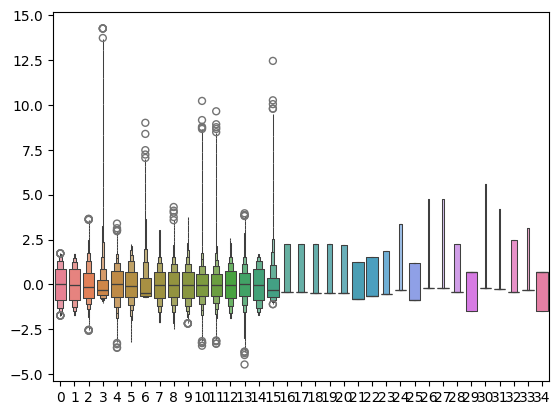

In [111]:
sns.boxenplot(x_train)

In [118]:
df.to_csv('processed_csv.csv')